# Table of Contents
1. [Problem Statement and Data Description](#Problem-Statement-and-Data-Description)  
       [Subsections](#Subsections) if needed
2. [Data Preprocessing](#Data-Preprocessing)
3. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
4. [Data splitting](#Data-splitting)
5. [Modeling](#Modeling)
6. [Hyperparameter Tuning](#Hyperparameter-Tuning)
7. [Model Evaluation](#Model-Evaluation)  
       [Model Brief](#Model-Brief) per model, documenting decisions, approach, limitations, etc.
8. [Model Selection and Results](#Model-Selection-and-Results)  
9. [Discussion](#Discussion)
10. [Conclusion](#Conclusion) including ideas beyond the scope of the course (this is stated in the deliverable)

In [1]:
# all imports in this cell per instructions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Problem Statement and Data Description

## Subsections

# Data Preprocessing

## 2. Data Preprocessing

### 2.1 Initial Data Inspection

### 2.2 Missing Values and Duplicates

### 2.3 Categorical Variable Validation

### 2.4 Outlier Assessment

### 2.5 Correlated Features

### 2.6 Preprocessing Summary

In [2]:
df = pd.read_excel(
    "default of credit card clients.xls",
    header=1
)

In [10]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.shape

(30000, 25)

### 2.1 Initial Data Inspection

The dataset was first examined to understand its dimensions, variable names,
data types, and overall structure before performing data cleaning and
preprocessing.

In [4]:
# Inspect dataset dimensions and column names
print(f"Dataset shape: {df.shape}")

print("\nColumn names:")
print(df.columns.tolist())

df.head()

Dataset shape: (30000, 25)

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
# Review data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [6]:
df = df.rename(
    columns={"default payment next month": "DEFAULT"}
)

print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


### 2.2 Missing Values

Missing values were evaluated across all variables to determine whether
imputation or removal would be required before modeling.

In [7]:
# Check missing values in each column
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percent": (missing_values / len(df)) * 100
})

missing_summary

,Missing_Count,Missing_Percent
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


In [8]:
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

Total missing values: 0


### 2.3 Duplicate and Identifier Check

Duplicate observations and customer identifiers were examined to prevent
redundant records or non-predictive identifiers from affecting the models.

In [9]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [10]:
# Check whether ID uniquely identifies each observation
print(f"Number of observations: {len(df)}")
print(f"Number of unique IDs: {df['ID'].nunique()}")

Number of observations: 30000
Number of unique IDs: 30000


In [11]:
# Remove customer identifier because it is not a predictive feature
df = df.drop(columns=["ID"])

print(f"Dataset shape after removing ID: {df.shape}")

Dataset shape after removing ID: (30000, 24)


### 2.4 Categorical Variable Validation

Categorical variables were reviewed to verify that their observed values were
consistent with the categories documented in the dataset description. Particular
attention was given to demographic variables because undocumented category
codes may require recoding before modeling.

In [12]:
# Review categorical variable values
categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


SEX:
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [13]:
# Consolidate undocumented categorical codes into "Other"
df["EDUCATION"] = df["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

df["MARRIAGE"] = df["MARRIAGE"].replace({
    0: 3
})

In [14]:
# Verify cleaned categorical values
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


SEX:
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [15]:
# Review repayment status values
pay_status_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in pay_status_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


PAY_0:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2:
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3:
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4:
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5:
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6:
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype

**Repayment Status Review:** The repayment-history variables contained the
expected delinquency codes as well as values of -2 and 0, which are not fully
defined in the supplied variable documentation. Because these values occur
frequently and may represent meaningful payment states, they were retained
during initial cleaning rather than being removed or arbitrarily recoded.
Their treatment will be considered during model-specific preprocessing.

### 2.5 Outlier Assessment

Potential outliers were examined for the continuous financial and demographic
variables. Because unusually large credit limits, bill balances, and payment
amounts may represent legitimate customer behavior, the purpose of this step
was to identify extreme observations rather than automatically remove them.

In [16]:
# Continuous variables considered for outlier assessment
numeric_cols = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Variable": col,
        "Outlier_Count": outlier_count,
        "Outlier_Percent": round(
            outlier_count / len(df) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Outlier_Count,Outlier_Percent
0,LIMIT_BAL,167,0.56
1,AGE,272,0.91
2,BILL_AMT1,2400,8.00
3,BILL_AMT2,2395,7.98
4,BILL_AMT3,2469,8.23
5,BILL_AMT4,2622,8.74
6,BILL_AMT5,2725,9.08
7,BILL_AMT6,2693,8.98
8,PAY_AMT1,2745,9.15
9,PAY_AMT2,2714,9.05


**Interpretation:** The IQR method identified relatively few potential
outliers in `LIMIT_BAL` and `AGE`, while approximately 8–10% of observations
were flagged in the monthly bill and payment amount variables. These financial
variables are expected to have skewed distributions because customers can have
substantially different credit balances and payment amounts.

The identified observations were therefore treated as potential extreme values
rather than automatic data errors. No observations were removed solely based
on the IQR criterion because doing so could eliminate legitimate high-value
customers and distort the underlying credit-risk patterns. Extreme values were
retained for modeling, with scaling or transformation to be considered later
within model-specific preprocessing pipelines.

In [17]:
# Review ranges of continuous variables for plausibility
range_summary = df[numeric_cols].agg(
    ["min", "median", "max"]
).T

range_summary

,min,median,max
LIMIT_BAL,10000.0,140000.0,1000000.0
AGE,21.0,34.0,79.0
BILL_AMT1,-165580.0,22381.5,964511.0
BILL_AMT2,-69777.0,21200.0,983931.0
BILL_AMT3,-157264.0,20088.5,1664089.0
BILL_AMT4,-170000.0,19052.0,891586.0
BILL_AMT5,-81334.0,18104.5,927171.0
BILL_AMT6,-339603.0,17071.0,961664.0
PAY_AMT1,0.0,2100.0,873552.0
PAY_AMT2,0.0,2009.0,1684259.0


### 2.6 Correlated Features

Correlations among continuous predictors were examined to identify potential
multicollinearity. This is particularly important for the six monthly bill
amount variables because measurements from consecutive months may contain
overlapping information.

In [18]:
# Calculate correlations among continuous predictors
correlation_matrix = df[numeric_cols].corr()

correlation_matrix.round(2)

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.00,0.14,0.29,0.28,0.28,0.29,0.30,0.29,0.20,0.18,0.21,0.20,0.22,0.22
AGE,0.14,1.00,0.06,0.05,0.05,0.05,0.05,0.05,0.03,0.02,0.03,0.02,0.02,0.02
BILL_AMT1,0.29,0.06,1.00,0.95,0.89,0.86,0.83,0.80,0.14,0.10,0.16,0.16,0.17,0.18
BILL_AMT2,0.28,0.05,0.95,1.00,0.93,0.89,0.86,0.83,0.28,0.10,0.15,0.15,0.16,0.17
BILL_AMT3,0.28,0.05,0.89,0.93,1.00,0.92,0.88,0.85,0.24,0.32,0.13,0.14,0.18,0.18
BILL_AMT4,0.29,0.05,0.86,0.89,0.92,1.00,0.94,0.90,0.23,0.21,0.30,0.13,0.16,0.18
BILL_AMT5,0.30,0.05,0.83,0.86,0.88,0.94,1.00,0.95,0.22,0.18,0.25,0.29,0.14,0.16
BILL_AMT6,0.29,0.05,0.80,0.83,0.85,0.90,0.95,1.00,0.20,0.17,0.23,0.25,0.31,0.12
PAY_AMT1,0.20,0.03,0.14,0.28,0.24,0.23,0.22,0.20,1.00,0.29,0.25,0.20,0.15,0.19
PAY_AMT2,0.18,0.02,0.10,0.10,0.32,0.21,0.18,0.17,0.29,1.00,0.24,0.18,0.18,0.16


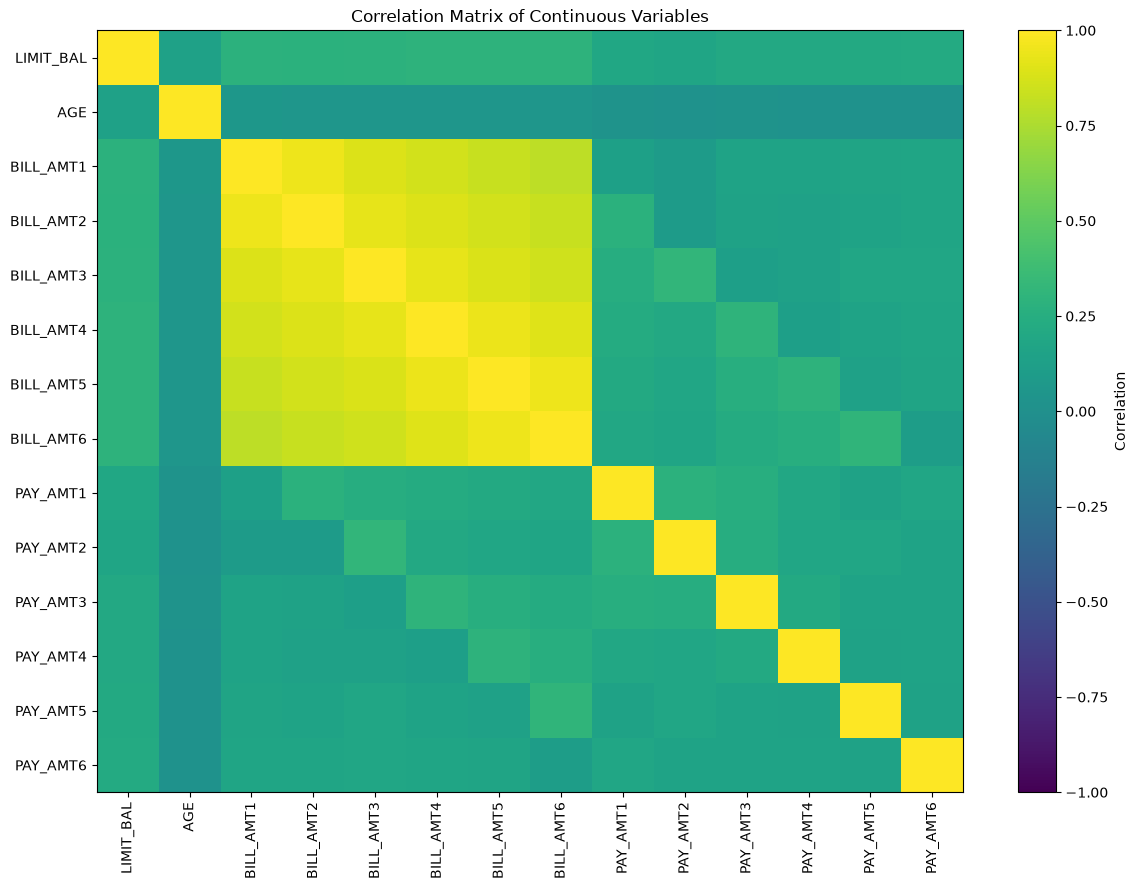

In [19]:
plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_cols)),
    numeric_cols,
    rotation=90
)

plt.yticks(
    range(len(numeric_cols)),
    numeric_cols
)

plt.title("Correlation Matrix of Continuous Variables")
plt.tight_layout()
plt.show()

**Interpretation:** The correlation analysis revealed substantial
multicollinearity among the six monthly bill amount variables. Correlations
between several `BILL_AMT` variables exceeded 0.80, with adjacent months
showing particularly strong relationships of approximately 0.90 or greater.
This is expected because these variables represent repeated monthly balances
for the same customers.

In contrast, the payment amount variables, age, and credit limit generally
showed low to moderate correlations with the other continuous predictors.
Because the project will evaluate both linear and tree-based models, the highly
correlated bill variables were retained in the cleaned master dataset rather
than automatically removed. Their impact will be evaluated during
model-specific preprocessing, since multicollinearity is more relevant for
models such as logistic regression and LDA than for tree-based methods such as
decision trees and random forests.

In [20]:
# Identify highly correlated feature pairs
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append({
                "Variable_1": correlation_matrix.columns[i],
                "Variable_2": correlation_matrix.columns[j],
                "Correlation": round(corr_value, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

high_corr_df.sort_values(
    by="Correlation",
    ascending=False
).reset_index(drop=True)

,Variable_1,Variable_2,Correlation
0,BILL_AMT2,BILL_AMT1,0.951
1,BILL_AMT6,BILL_AMT5,0.946
2,BILL_AMT5,BILL_AMT4,0.940
3,BILL_AMT3,BILL_AMT2,0.928
4,BILL_AMT4,BILL_AMT3,0.924
5,BILL_AMT6,BILL_AMT4,0.901
6,BILL_AMT3,BILL_AMT1,0.892
7,BILL_AMT4,BILL_AMT2,0.892
8,BILL_AMT5,BILL_AMT3,0.884
9,BILL_AMT5,BILL_AMT2,0.860


### 2.7 Data Preprocessing Summary

The preprocessing assessment identified no missing observations or duplicate
records. The customer `ID` variable was removed because it served only as a
unique identifier. Undocumented values in `EDUCATION` and `MARRIAGE` were
consolidated into their existing "Other" categories, while ambiguous repayment
status codes were retained to avoid making unsupported assumptions about their
meaning.

Potential outliers were identified using the IQR method. Because extreme
financial values may represent legitimate customer behavior, no observations
were removed solely for being statistical outliers. Correlation analysis
identified substantial multicollinearity among the monthly bill amount
variables; however, these variables were retained in the cleaned master dataset
so that their treatment can be evaluated within the appropriate modeling
pipelines.

The resulting dataset is therefore cleaned while preserving potentially useful
credit-risk information for subsequent data splitting and model development.

In [21]:
# Create cleaned master dataset for subsequent analysis
df_clean = df.copy()

print(f"Final cleaned dataset shape: {df_clean.shape}")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")

Final cleaned dataset shape: (30000, 24)
Total missing values: 0


# Exploratory Data Analysis